# Model training and Evaluation

In [1]:
import sys
import os

# Add parent directory to Python path
parent_dir = os.path.abspath("/home/e90244aa/Bleep/DeepPathway/")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

## Loading Libraries

In [2]:
import config as cfg
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import torch
import random
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import config as cfg
import numpy as np
import torch.nn.functional as F
from numpy.linalg import norm
from scipy import stats
from data_loaders import build_loaders, build_loaders_inference
from models import BLEEPOnly, BLEEPWithOptimus, BLEEP_MLP, DeepPathway
from utils import *
from spatialdata import read_zarr
import scanpy as sc
from visualization import plot_sdata
import math
import os

/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [3]:
seed=cfg.seed
random.seed(seed)

# Set seed for NumPy
np.random.seed(seed)

# Set seed for PyTorch
torch.manual_seed(seed)

# Set seed for CUDA
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior in CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for Python hash
torch.use_deterministic_algorithms(True) #newly added line
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8" #newly added line

os.environ['PYTHONHASHSEED'] = str(seed)

In [4]:
def train_epoch(model, train_loader, optimizer, lr_scheduler=None):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(train_loader, total=len(train_loader))
    for batch in tqdm_object:
        batch = {k: v.cuda(cfg.device) for k, v in batch.items() if k == "image" or k == "reduced_expression" or k =='pos encodings' or k =='st_feat'}
        optimizer.zero_grad()
        loss = model(batch)
        loss.backward()
        optimizer.step()
        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)
        tqdm_object.set_postfix(train_loss=loss_meter.avg, lr=get_lr(optimizer))
    return loss_meter


def test_epoch(model, test_loader):
    loss_meter = AvgMeter()
    tqdm_object = tqdm(test_loader, total=len(test_loader))
    for batch in tqdm_object:
        batch = {k: v.cuda(cfg.device) for k, v in batch.items() if k == "image" or k == "reduced_expression" or k =='pos encodings' or k =='st_feat'}
        loss = model(batch)
        count = batch["image"].size(0)
        loss_meter.update(loss.item(), count)
        tqdm_object.set_postfix(valid_loss=loss_meter.avg)
    return loss_meter

In [5]:
tr_loss = []
tst_loss = []
best_loss = float('inf')
best_epoch = 0

## Selecting Model

In [6]:
model=DeepPathway().to(cfg.device)
print("Model is DeepPathway using Image Encoder of ResNet18")

Model is DeepPathway using Image Encoder of ResNet18


## Building Loader

In [7]:
print("Finished Loading Model.....:", cfg.method)
train_loader, test_loader=build_loaders(cfg.train_samples,cfg.root_path)
save_path=cfg.root_path + "saved_weights/itr_01_" + cfg.method + "_" + cfg.dataset + "_pathways_" + cfg.test_sample + ".pt"
early_stopping=EarlyStopping(patience=cfg.patience, verbose=True,path=save_path)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
print("Training Started of Model",cfg.method)

Finished Loading Model.....: DeepPathway
Building loaders
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
13135 3284
train/test split completed
Finished building loaders
Training Started of Model DeepPathway


## Training

In [8]:
for epoch in range(cfg.epochs):
    print(f"Epoch: {epoch + 1}")
    model.train()
    train_loss = train_epoch(model, train_loader, optimizer)
    tr_loss.append(train_loss.avg)

    model.eval()
    with torch.no_grad():
        test_loss = test_epoch(model, test_loader)
        lss = test_loss.avg
        tst_loss.append(lss)

    if lss < best_loss:
        best_loss = lss
        best_epoch = epoch
        print(f"Best loss at Epoch: {epoch + 1}")
        torch.save(model.state_dict(), save_path)
    # Early Stopping Check
    early_stopping(lss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

Epoch: 1


100%|█████████████████████████| 52/52 [00:07<00:00,  6.58it/s, valid_loss=0.196]


Best loss at Epoch: 1
Validation loss decreased. Saving model to /home/e90244aa/Bleep/DeepPathwayV3/prostate cancer dataset/saved_weights/itr_01_DeepPathway_prostate_pathways_MEND154.pt
Epoch: 2


100%|█████████████████████████| 52/52 [00:07<00:00,  6.62it/s, valid_loss=0.191]


Best loss at Epoch: 2
Validation loss decreased. Saving model to /home/e90244aa/Bleep/DeepPathwayV3/prostate cancer dataset/saved_weights/itr_01_DeepPathway_prostate_pathways_MEND154.pt
Epoch: 3


...

EarlyStopping counter: 3 out of 5
Epoch: 9


100%|█████████████████████████| 52/52 [00:07<00:00,  6.52it/s, valid_loss=0.187]


EarlyStopping counter: 4 out of 5
Epoch: 10


100%|█████████████████████████| 52/52 [00:08<00:00,  6.47it/s, valid_loss=0.187]

EarlyStopping counter: 5 out of 5
Early stopping


## Testing

In [9]:
def get_predictions(test_loader,model_path, model,model_tag=None):
    state_dict = torch.load(model_path)
    model.load_state_dict(state_dict)
    model.eval()
    print("Finished loading model")

    test_image_embeddings = []
    test_expression_embeddings = []
    with torch.no_grad():
        for batch in tqdm(test_loader):
            images = batch["image"].cuda()
            optim_feat = batch['st_feat'].cuda()
            expression = batch['reduced_expression'].cuda()
            if model_tag=="BLEEPOnly":
                image_features = model.image_encoder(images)
                image_embeddings=model.image_projection(image_features)
                expression_embedding = model.spot_projection(expression)
            elif model_tag=="BLEEPWithOptimus":
                image_features = model.image_encoder(images)
                image_features = torch.cat((image_features, optim_feat), dim=1)
                image_embeddings=model.image_projection(image_features)
                expression_embedding = model.spot_projection(expression)
            elif model_tag=="DeepPathway":
                image_features = model.image_model.image_encoder(images)
                image_features = torch.cat((image_features, optim_feat), dim=1)
                image_features = model.image_model.image_projection(image_features)
                image_embeddings = model.img_linear(image_features) # here it is direct prediction
                expression_embedding=expression
            else:
                image_features = model.image_model.image_encoder(images)
                image_embeddings=model.image_model.image_projection(image_features)
                image_embeddings=model.img_linear(image_features)
                expression_embedding=expression   # just to avoid errors, pasted the same GT expression.
            test_image_embeddings.append(image_embeddings)
            test_expression_embeddings.append(expression_embedding)
    return torch.cat(test_image_embeddings), torch.cat(test_expression_embeddings)

def metrics_calculation(true,pred):
    corr_cells = np.zeros(pred.shape[0])
    sp_corr_cells = np.zeros(pred.shape[0])
    cosine_cells = np.zeros(pred.shape[0])
    for i in range(pred.shape[0]):
        corr_cells[i] = np.corrcoef(pred[i, :], true[i, :])[0, 1]
        sp_corr_cells[i] = stats.spearmanr(pred[i, :], true[i, :])[0]
        cosine_cells[i] = np.dot(pred[i, :], true[i, :]) / (norm(pred[i, :]) * norm(true[i, :]))

    corr_cells = corr_cells[~np.isnan(corr_cells)]
    sp_corr_cells = sp_corr_cells[~np.isnan(sp_corr_cells)]
    cosine_cells = cosine_cells[~np.isnan(cosine_cells)]

    print("Mean Pearson correlation across All spots (pathwaywuse correlation): ", np.mean(corr_cells))
    print("Mean Spearman correlation across spots: ", np.mean(sp_corr_cells))
    print("Mean Cosine Similarity across spots: ", np.mean(cosine_cells))

    corr_pathways = np.zeros(pred.shape[1])
    sp_corr_paths = np.zeros(pred.shape[1])
    cosine_pathways = np.zeros(pred.shape[1])
    for i in range(pred.shape[1]):
        corr_pathways[i] = np.corrcoef(pred[:, i], true[:, i], )[0, 1]
        sp_corr_paths[i] = stats.spearmanr(pred[:, i], true[:, i])[0]
        cosine_pathways[i] = np.dot(pred[:, i], true[:, i]) / (norm(pred[:, i]) * norm(true[:, i]))

    corr_pathways = corr_pathways[~np.isnan(corr_pathways)]
    sp_corr_paths = sp_corr_paths[~np.isnan(sp_corr_paths)]
    cosine_pathways = cosine_pathways[~np.isnan(cosine_pathways)]

    print("Mean Pearson correlation across pathways: ", np.mean(corr_pathways))

    print("Mean Spearman correlation across pathways: ", np.mean(sp_corr_paths))
    print("Mean Cosine Similarity across pathways: ", np.mean(cosine_pathways))
    true_filetered = []
    for k in range(0, corr_pathways.shape[0]):
        if corr_pathways[k] == np.nan:
            continue
        else:
            true_filetered.append(true[:, k])
    true_filetered = np.array(true_filetered).T
    print(true_filetered.shape)
    ind = np.argsort(np.sum(true_filetered, axis=0))[-5:]
    # print("highly expressed indices",ind)
    print("mean Pearson correlation highly expressed pathways: ", np.mean(corr_pathways[ind]))
    # print("mean Spearman correlation highly expressed pathways: ", np.mean(sp_corr_paths[ind]))
    ind = np.argsort(np.var(true_filetered, axis=0))[-5:]
    # print("highly variable indices",ind)
    print("mean Pearson correlation highly variable pathways: ", np.mean(corr_pathways[ind]))
    # print("mean Spearman correlation highly variable pathways: ", np.mean(sp_corr_paths[ind]))
    return

def copy_adata(adata_true,adata_pred):
    adata_pred.obs = adata_true.obs
    adata_pred.uns = adata_true.uns
    adata_pred.var_names = adata_true.var_names
    adata_pred.obsm = adata_true.obsm
    return adata_pred

def contains_nan(sublist):
    return any(isinstance(item, float) and math.isnan(item) for item in sublist)

def get_top_k_pathways(true,pred,pathway_names,k=5):
    res=[]
    top_pathways=[]
    for i in range(0,pred.shape[1]):
        x = np.corrcoef(true[:, i], pred[:, i])[0, 1]
        res.append([i, x])
    cleaned_data = [sublist for sublist in res if not contains_nan(sublist)]
    sorted_data = sorted(cleaned_data, key=lambda x: x[1], reverse=True)
    for i in range(0,k):
        top_pathways.append(pathway_names[sorted_data[i][0]])
    return top_pathways


In [10]:
cfg.test_sample

'MEND154'

In [11]:
print(cfg.root_path  + "saved_weights/itr_01_"+ cfg.method + "_" + cfg.dataset + "_pathways_" + cfg.test_sample + ".pt")

/home/e90244aa/Bleep/DeepPathwayV3/prostate cancer dataset/saved_weights/itr_01_DeepPathway_prostate_pathways_MEND154.pt


### Evaluation Using DeepPathway

Building loaders
Finished loading all files
Finished building inference loaders
Finished loading model


100%|███████████████████████████████████████████| 10/10 [00:05<00:00,  1.69it/s]


Mean Pearson correlation across All spots (pathwaywuse correlation):  0.8962457757153155
Mean Spearman correlation across spots:  0.8625030540065358
Mean Cosine Similarity across spots:  0.9813730726611873
Mean Pearson correlation across pathways:  0.4885707567207814
Mean Spearman correlation across pathways:  0.4942877647008878
Mean Cosine Similarity across pathways:  0.9663825285985634
(2546, 47)
mean Pearson correlation highly expressed pathways:  0.7131083524821181
mean Pearson correlation highly variable pathways:  0.6705896505857978
INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
AnnData object with n_obs × n_vars = 2546 × 47
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'region', 'spot_id'
    uns: 'spatialdata_attrs'
INFO     Rasterizing image for faster rendering.                                                                   


/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `spots` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `adata_true` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Rasterizing image for faster rendering.                                                                   


...

/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `spots` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `adata_pred` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Rasterizing image for faster rendering.                                                                   


/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `spots` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `adata_pred` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Rasterizing image for faster rendering.                                                                   


/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `spots` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/e90244aa/anaconda3/envs/mybleep/lib/python3.10/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `adata_pred` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


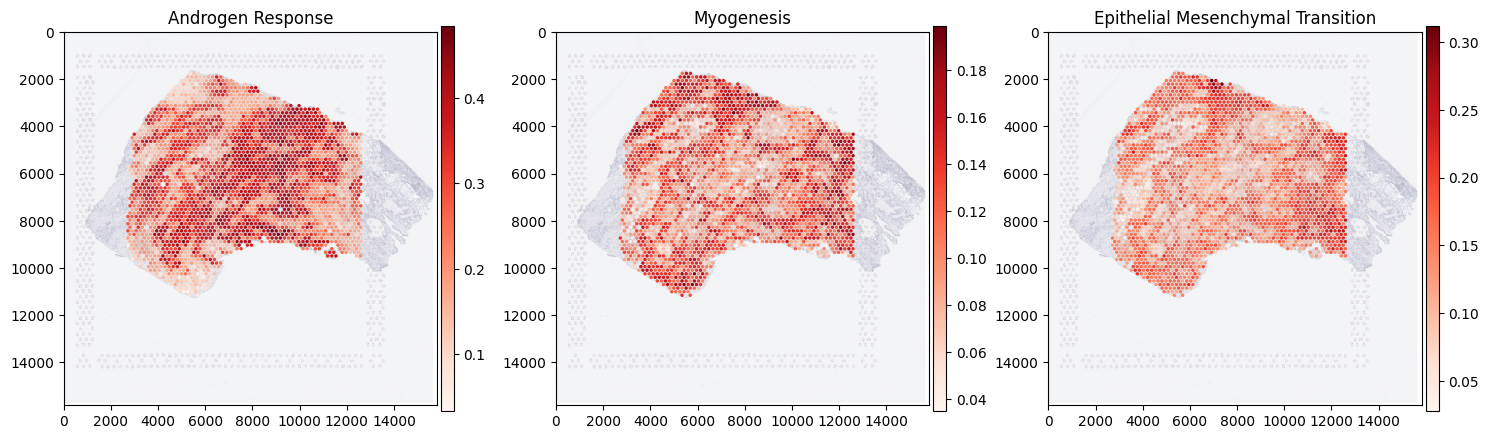

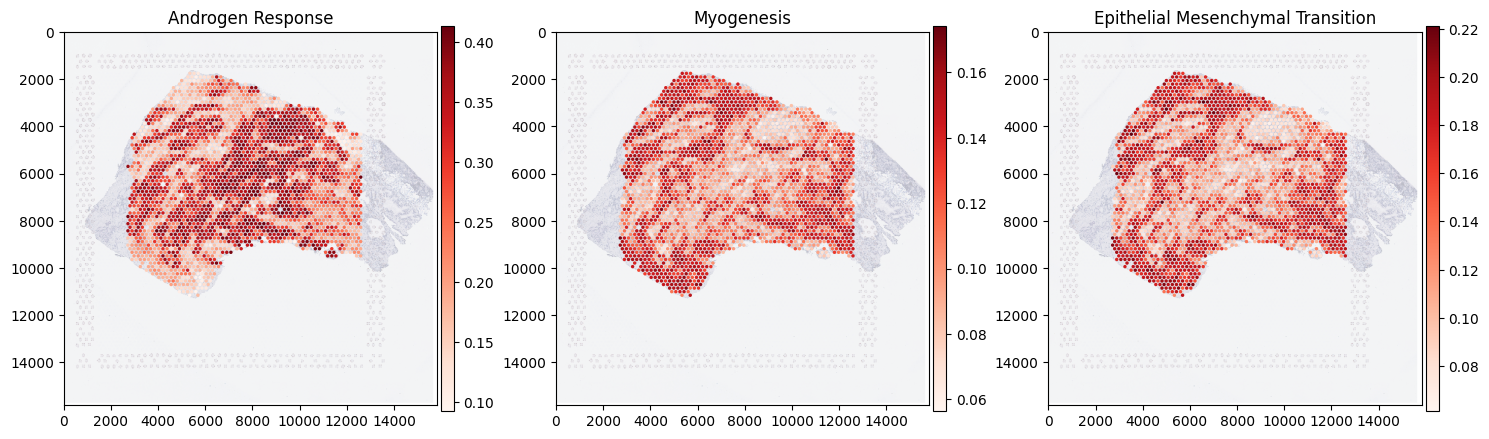

In [12]:
sdata = read_zarr(cfg.root_path+"SpatialData/"+cfg.test_sample+"_spatial_data.zarr")
true=sdata['adata_pathways'].X
test_loader = build_loaders_inference([cfg.test_sample], cfg.root_path)
model_path = cfg.root_path  + "saved_weights/itr_01_" + cfg.method + "_" + cfg.dataset + "_pathways_" + cfg.test_sample + ".pt"
model = DeepPathway().to('cuda:0')
pred, _ = get_predictions(test_loader,model_path, model,model_tag="DeepPathway")
pred  = pred.cpu().numpy()
adata_preds = copy_adata(sdata['adata_pathways'], sc.AnnData(X=pred))
method=str()
if "+" in cfg.method:
    method = cfg.method.replace("+","_")
else:
    method = cfg.method
sdata.tables['predictions_' + method] = adata_preds
# sdata.write(cfg.root_path + "/SpatialData/" + cfg.test_sample + "_spatial_data.zarr", overwrite=True)
metrics_calculation(true,pred)
top_k_pathways = get_top_k_pathways(true, pred, sdata['adata_pathways'].var_names.tolist(), k=3)
plot_sdata(sdata, cfg.test_sample,top_k_pathway_names=top_k_pathways)